In [1]:
%load_ext autoreload
%autoreload 2

import os

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from utils import *

## Fig. 7 - Kernel-level Power Prediction Validation

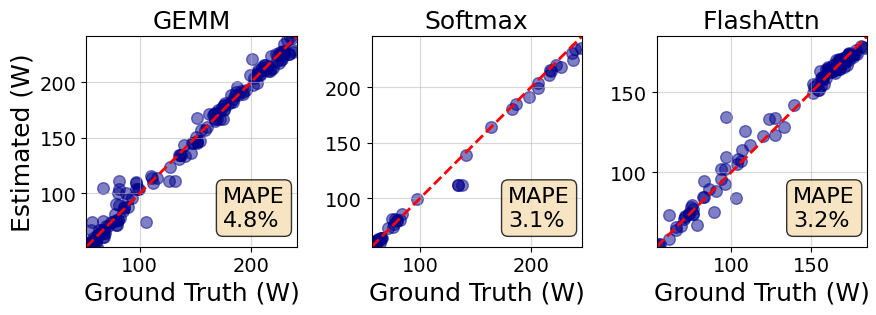

In [2]:
result_folder = '../experiments_single/results'
result_seed = 1 # Change this if you used different random seed when running run_single.sh
fig7_plot(result_folder, result_seed)

## Fig. 9 - End to End Latency and Power Predictions for A100 and A10

Li MAPE: 13.70 %
NeuSight MAPE: 15.92 %
GEE MAPE: 11.65 %
GEE POWER MAPE: 8.26 %


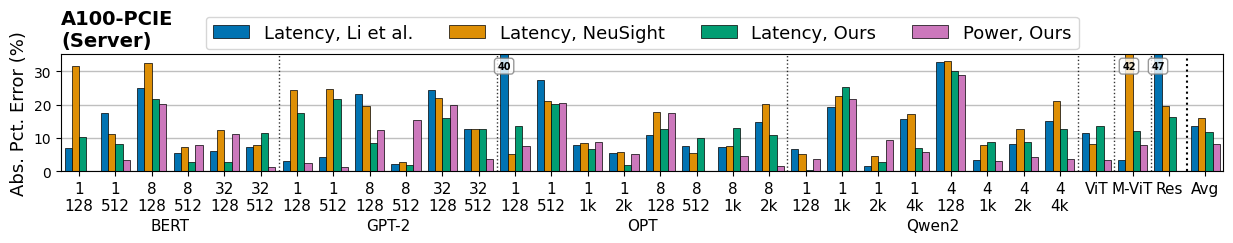

In [3]:
df = pd.read_csv('../experiments_endtoend/reports/a100_endtoend/all.csv')
df_to_plot = df.loc[((df['model'] == 'bertmodel') & ((df['batch'] == 1) | (df['batch'] == 8) | (df['batch'] == 32)) & ((df['seq'] == 128) | (df['seq'] == 512))) |
                    ((df['model'] == 'gpt2model') & ((df['batch'] == 1) | (df['batch'] == 8) | (df['batch'] == 32)) & ((df['seq'] == 128) | (df['seq'] == 512))) |
                    ((df['model'] == 'optmodel') & ((df['batch'] == 1) | (df['batch'] == 8)) & ((df['seq'] == 128) | (df['seq'] == 512) | (df['seq'] == 1024) | (df['seq'] == 2048))) |
                    ((df['model'] == 'qwen2model') & ((df['batch'] == 1) | (df['batch'] == 4)) & ((df['seq'] == 128) | (df['seq'] == 1024) | (df['seq'] == 2048) | (df['seq'] == 4096))) |
                    ((df['model'] == 'vitmodel') & (df['batch'] == 32)) | ((df['model'] == 'resnet101') & (df['batch'] == 64)) | ((df['model'] == 'mobilevitmodel') & (df['batch'] == 64))]
df_to_plot.to_csv('a100_to_plot.csv', index=False)

labelmap = {
    'bertmodel': 'BERT',
    'gpt2model': 'GPT-2',
    'mobilevitmodel': 'M-ViT',
    'optmodel': 'OPT',
    'qwen2model': 'Qwen2',
    'resnet101': 'Res',
    'vitmodel': 'ViT'
}

# Define model order (optional - controls the order models appear on x-axis)
model_order = ['bertmodel', 'gpt2model', 'optmodel', 'qwen2model', 'vitmodel',
                'mobilevitmodel', 'resnet101', ]

# Create the plot
fig, ax = fig9_plot_grouped_error_bars(
    'a100_to_plot.csv',  # Replace with your CSV path
    labelmap,
    model_order=model_order,
    figsize=(15, 1.6),
    title='A100-PCIE\n(Server)'
)

Li MAPE: 29.96 %
NeuSight MAPE: 9.60 %
GEE MAPE: 9.65 %
GEE POWER MAPE: 8.05 %


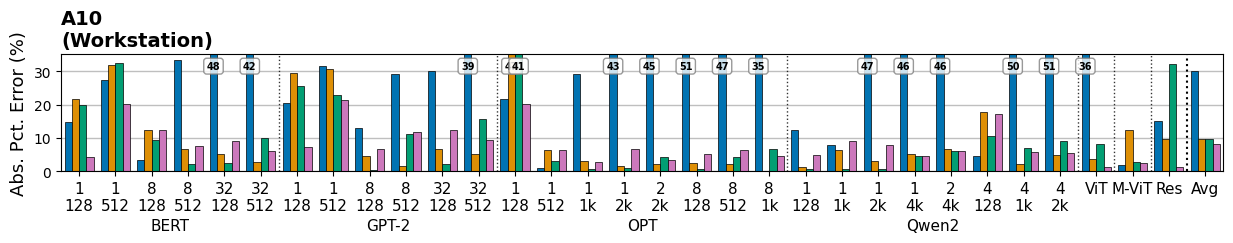

In [4]:
df = pd.read_csv('../experiments_endtoend/reports/a10_endtoend/all.csv')
df_to_plot = df.loc[((df['model'] == 'bertmodel') & ((df['batch'] == 1) | (df['batch'] == 8) | (df['batch'] == 32)) & ((df['seq'] == 128) | (df['seq'] == 512))) |
                    ((df['model'] == 'gpt2model') & ((df['batch'] == 1) | (df['batch'] == 8) | (df['batch'] == 32)) & ((df['seq'] == 128) | (df['seq'] == 512))) |
                    ((df['model'] == 'optmodel') & (df['batch'] == 1) & ((df['seq'] == 128) | (df['seq'] == 512) | (df['seq'] == 1024) | (df['seq'] == 2048))) |
                    ((df['model'] == 'optmodel') & (df['batch'] == 2) & (df['seq'] == 2048)) |
                    ((df['model'] == 'optmodel') & (df['batch'] == 8) & ((df['seq'] == 128) | (df['seq'] == 512) | (df['seq'] == 1024))) |
                    ((df['model'] == 'qwen2model') & (df['batch'] == 1) & ((df['seq'] == 128) | (df['seq'] == 1024) | (df['seq'] == 2048) | (df['seq'] == 4096))) |
                    ((df['model'] == 'qwen2model') & (df['batch'] == 2) & (df['seq'] == 4096)) |
                    ((df['model'] == 'qwen2model') & (df['batch'] == 4) & ((df['seq'] == 128) | (df['seq'] == 1024) | (df['seq'] == 2048))) |
                    ((df['model'] == 'vitmodel') & (df['batch'] == 32)) | ((df['model'] == 'resnet101') & (df['batch'] == 64)) | ((df['model'] == 'mobilevitmodel') & (df['batch'] == 64))]

df_to_plot.to_csv('a10_to_plot.csv', index=False)

labelmap = {
    'bertmodel': 'BERT',
    'gpt2model': 'GPT-2',
    'mobilevitmodel': 'M-ViT',
    'optmodel': 'OPT',
    'qwen2model': 'Qwen2',
    'resnet101': 'Res',
    'vitmodel': 'ViT'
}

# Define model order (optional - controls the order models appear on x-axis)
model_order = ['bertmodel', 'gpt2model', 'optmodel', 'qwen2model', 'vitmodel',
                'mobilevitmodel', 'resnet101', ]

# Create the plot
fig, ax = fig9_plot_grouped_error_bars(
    'a10_to_plot.csv',
    labelmap,
    model_order=model_order,
    figsize=(15, 1.6),
    title='A10\n(Workstation)',
    no_legend=True
)

## Fig. 10(a) - Kernel-level Latency Prediction Comparisons

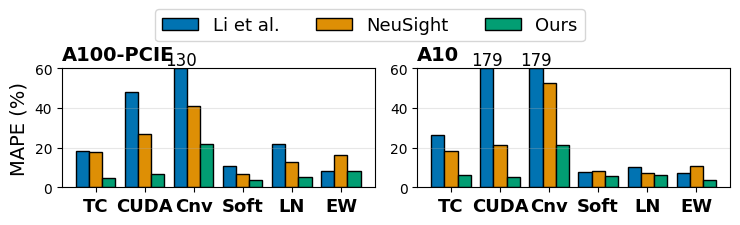

In [5]:
result_folder = '../experiments_single/results'
result_seed = 1 # Change this if you used different random seed when running run_single.sh
fig10_plot(result_folder, result_seed)

## Fig. 11 - Voltage Frequency Scaling

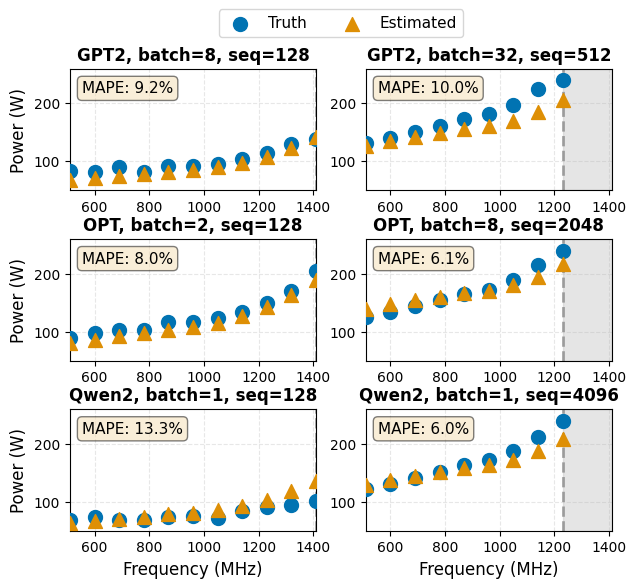

In [6]:
# Read the CSV file
df = pd.read_csv('../experiments_endtoend/reports/dvfs/dvfs.csv')

configurations = [
    ('gpt2model', 'gpt2', 8, 128, 'prefill'),
    ('gpt2model', 'gpt2', 32, 512, 'prefill'),
    ('optmodel', 'opt-1p3b', 2, 128, 'prefill'),
    ('optmodel', 'opt-1p3b', 8, 2048, 'prefill'),
    ('qwen2model', 'qwen2-1p5b', 1, 128, 'prefill'),
    ('qwen2model', 'qwen2-1p5b', 1, 4096, 'prefill'),
]

model_name_map = {
    'bertmodel': 'BERT', 
    'gpt2model': 'GPT2', 
    'optmodel': 'OPT', 
    'qwen2model': 'Qwen2'
}

fig11_plot_dvfs(df, configurations, model_name_map)